# Imports and data

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
import matplotlib.pyplot as plt
from utils.publication_lags import apply_fred_md_publication_lag
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

repo_root = os.path.abspath('..')

# Bianchi period:
start_date = '1971-08-31'
end_date = '2018-12-31'
# end_date = '2025-06-30' # kr and gsw end date

maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

# adjust fred_md start_date by 6 months to fetch enough data for shifting
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# If wanted, apply per-series publication lag to latest-snapshot macro data
# from utils.publication_lags import apply_fred_md_publication_lag
# fred_md = apply_fred_md_publication_lag(fred_md_raw)  
# For results in paper, we naively shift all FRED-MD series by 1 month
# to reflect publication lag:
fred_md = fred_md_raw.shift(1)

fred_md_realtime = pd.read_csv(
    os.path.join(repo_root, 'data', 'ALFRED', 'simple_outputs', 'realtime_final_balanced.csv'),
    parse_dates=True,
    index_col=0
 )
fred_md_realtime.index.name = 'date'

# Drop TWEXAFEGSMTHx and ACOGNO as they start late
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
fred_md_realtime = fred_md_realtime.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'], errors='ignore')
# Finally, revert fred_md to start_date, after transformations and lag adjustments
fred_md = fred_md[start_date:end_date]
fred_md_realtime = fred_md_realtime[start_date:end_date]

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
fred_md_realtime = fred_md_realtime.loc[fred_md_realtime.index <= xr.index[-1]].reindex(xr.index)
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

X_realtime = pd.concat([fred_md_realtime, forward, yields],
                        axis=1,
                        keys=['fred', 'forward', 'yields'])
X_realtime = add_group_level(X_realtime, s2g, level_name='group')
X_realtime = X_realtime.sort_index(axis=1, level='group')
groups_realtime = groups_as_array(X_realtime, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


# Expanding window estimation

In [1]:
from models.base import *
from models.classical import *
from models.gbt import *
from models.linear import *
from models.tree import *
from tqdm import tqdm
from joblib import Parallel, delayed

OOS_start = pd.Timestamp('1990-01-31')

coefs = []

def record_coef(coef):
    coefs.append(np.abs(coef).copy())  # store absolute value

benchmark_models = {
    # 'RW': RandomWalkModel(),
    # 'Mean': HistoricalMeanModel(),
    # 'CP': CochranePiazzesiModel(),
    # 'LN': LudvigsonNgModel(),
    # 'LN_BH': LudvigsonNgBauerHamiltonSpec(),
    # 'Linear': LinearModel() # OLS on forward rates
}

macro_models = {
    # 'MacroExtraTrees': ExtraTreesModel(features={
    #     'forward': {'method': 'raw'},
    # }),
    # 'PCAPlusN': PCABaselineModelPlusN(components=3, series='forward', n_extra=1),
    # 'PCAMacroGroups': PCABaselineModelMacroGroups(components=3, series='forward', lasso=True, alpha=0.01, macro_pcs=0),
    # 'PCAMacroGroupsHYPERGRID': PCABaselineModelMacroGroupsHYPERGRID(components=3, series='forward', lasso=True)
    # 'PCAMacroGroupsNoLasso': PCABaselineModelMacroGroups(components=3, series='forward', lasso=False, alpha=0.01),
    # 'GroupPCARF': GroupPCARandomForest(components=3, series='forward', macro_pcs=1),
    # 'GroupPCARF2': GroupPCARandomForest(components=3, series='forward', macro_pcs=2),
    # 'GroupLasso': GroupLassoModel(groups=groups),
}

forward_only_models = {
    'lasso_forward': LassoModel(series='forward', alphas=[0]),
    # 'ridge_forward': RidgeModel(series='forward'),
    # 'pcr_forward': PCABaselineModel(components=3, series='forward'),
    # 'pcr_extra_trees_forward': ExtraTreesForwardModel(scale=True, use_pca=True, n_components=5, tune_every=60),
    # 'pcr_random_forest_forward': RandomForestForwardModel(scale=True, use_pca=True, n_components=5, tune_every=60),
}

tree_models = {
    # "Tree_RF": FwdFredTreeEnsemble1D(estimator="rf"),
    # "Tree_ET": FwdFredTreeEnsemble1D(estimator="ef"),
    # "Tree_XGB": FwdFredTreeEnsemble1D(estimator="xgb"),
    # "Tree_LGBM": FwdFredTreeEnsemble1D(estimator="lgbm"),

    # # Forward-only variants:
    # "Tree_RF_FwdOnly": FwdFredTreeEnsemble1D(estimator="rf", include_fred=False),
    # "Tree_ET_FwdOnly": FwdFredTreeEnsemble1D(estimator="ef", include_fred=False),
    # "Tree_XGB_FwdOnly": FwdFredTreeEnsemble1D(estimator="xgb", include_fred=False),
    # "Tree_LGBM_FwdOnly": FwdFredTreeEnsemble1D(estimator="lgbm", include_fred=False)
}

all_models = {**benchmark_models, **macro_models, **forward_only_models, **tree_models}

y = xr['120'].values # 10-year overlapping excess returns
# y = monthly_xr['120'].values # 1-month excess returns

for name, model in all_models.items():
    print(f"Running {name}...")
    y_forecast_bianchi = wu.expanding_window(
        model, X, y, dates, OOS_start, 
        gap=11,         # gap = 11 for annual yields
        refit_freq=1,     # Refit every month
    )

    r2 = wu.oos_r2(y, y_forecast_bianchi)
    print(f"Model: {name}\n R2_OOS = {r2:.4f}\n Significance: {bu.RSZ_Signif(y, y_forecast_bianchi):.3f}\n")   

ModuleNotFoundError: No module named 'models'

In [ ]:
MATURITIES = ['24','36','48','60','84','120']
MATURITIES = ['120']
for name, model in all_models.items():
    for maturity in tqdm(MATURITIES, desc=f"Evaluating {name} across maturities", position=0):
        y = xr[maturity].values

        y_forecast_bianchi = wu.expanding_window(
            model, X, y, dates, OOS_start, 
            gap=11,         # gap = 11 for annual nonoverlapping yields
            refit_freq=1,     # Refit every month
        ) 

        r2 = wu.oos_r2(y, y_forecast_bianchi)
        print(f"Model: {name}\tMaturity {maturity}:\n R2_OOS = {r2:.4f}\n Significance: {bu.RSZ_Signif(y, y_forecast_bianchi):.3f}\n")   

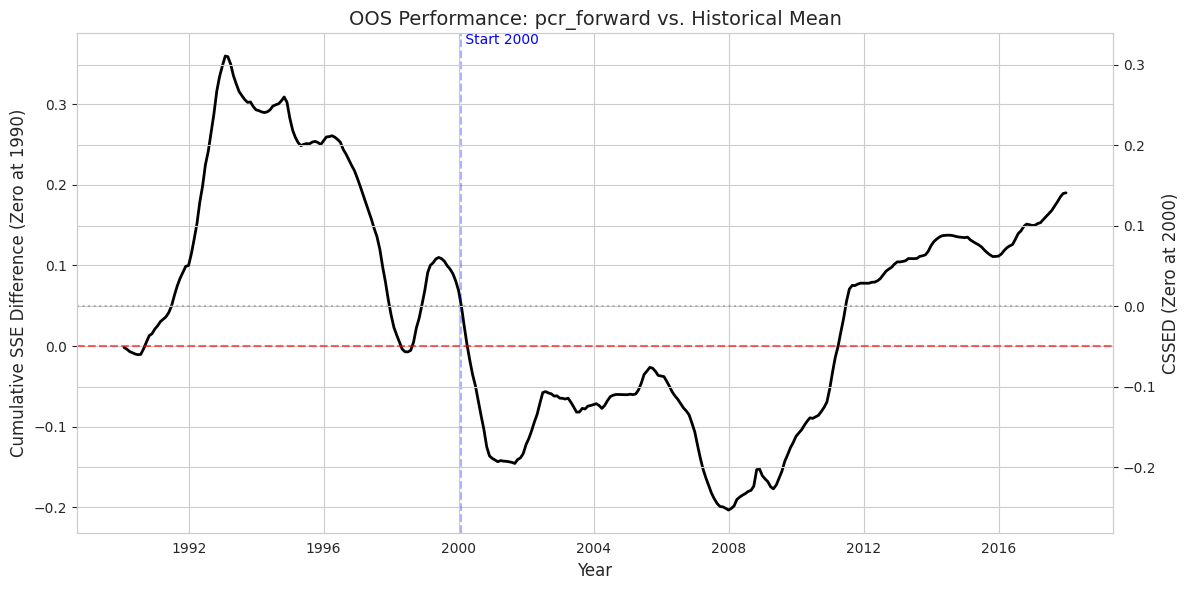

In [3]:
# After running wu.expanding_window:
secondary_zero = pd.Timestamp('2000-01-31')
bu.plot_cssed(y, y_forecast_bianchi, dates, OOS_start, secondary_start=secondary_zero, model_name=name)

<Axes: xlabel='date'>

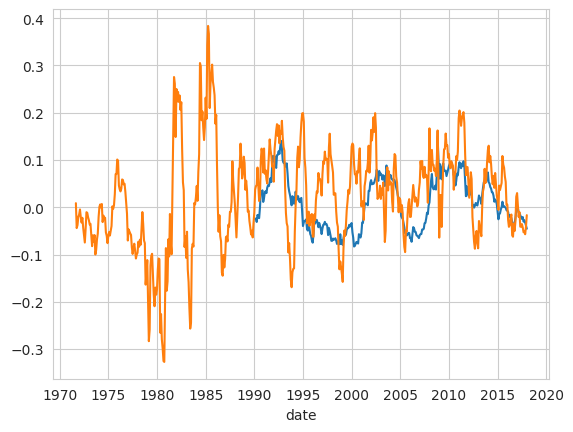

In [4]:
sns.lineplot(y=y_forecast_bianchi, x=yields.index)
sns.lineplot(y=y, x=yields.index)

# Neural networks with multiple outputs:

In [16]:
from models.macro_forward_ann import MacroForwardANNWrapper
from models.group_ensemble_ann import GroupEnsembleANNWrapper
from models.ann_vector_validation import PyTorchMLPWrapper

import importlib
import sys
importlib.reload(sys.modules['models.group_ensemble_ann'])
importlib.reload(sys.modules['models.macro_forward_ann'])
importlib.reload(sys.modules['models.ann_vector_validation'])


OOS_start = pd.Timestamp('1990-01-31')

# maturities = ['24', '36', '48', '60', '72', '84', '96', '108', '120']
maturities = ['24', '36', '48', '60', '84', '120']
# maturities = ['24']

y_all = xr[maturities].values
dates = monthly_xr.index

models_dict = {
    # 'FwdANN_1_3': PyTorchMLPWrapper(archi=(3,), lr=0.01, epochs=1000, tune_every=60,
    #     patience=50, param_grid={'penalty': [0, 0.01, 0.001, 0.0001]}, seed=1, use_pca=False, n_components=None, y_center=True),
    'MacroANN_1_3': MacroForwardANNWrapper(archi_forward=(3,), archi_macro=(32,16,8), lr=0.01, epochs=1000, tune_every=60,
        patience=50, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]}, seed=1, y_center=True),
    # 'GroupEnsemble_1_3': GroupEnsembleANNWrapper(archi_forward=(3,), archi_macro=(1,), lr=0.01, epochs=1000, tune_every=60,
    #     patience=20, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]}, seed=1, y_center=True),
}

# All use the same API:
# for name, model in models_dict.items():
#     y_forecast = wu.expanding_window(model, X, y_all, dates, OOS_start, gap=0, refit_freq=1)
#     r2s = wu.oos_r2(y_all, y_forecast, benchmark='hist_mean')
#     print(f"\n--- OOS R² Summary for {name} ---")
#     for mat, r2 in zip(maturities, r2s):
#         print(f"  {mat}m: {r2:.4f}")

<Axes: xlabel='date'>

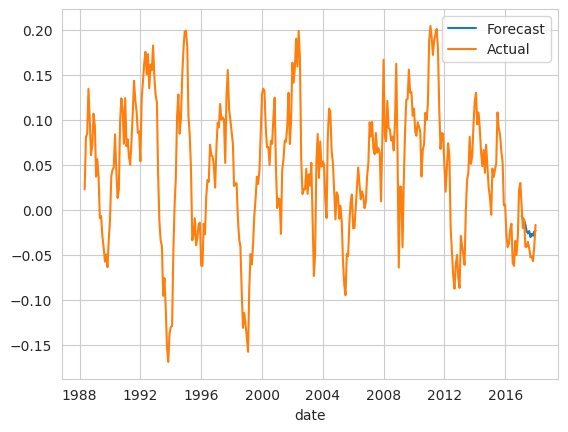

In [7]:
sns.lineplot(y=y_forecast[:, -1], x=yields.index, label='Forecast')
sns.lineplot(y=y_all[:, -1][200:], x=yields[200:].index, label='Actual')

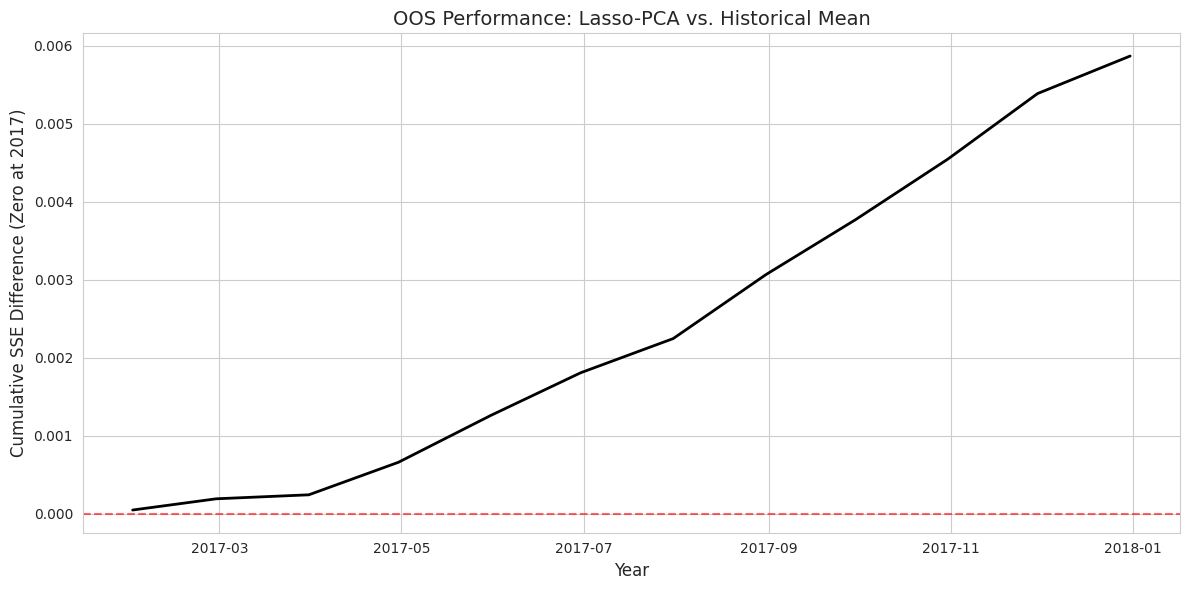

In [8]:
# After running wu.expanding_window:
bu.plot_cssed(y_all[:, -2], y_forecast[:, -2], dates, OOS_start, secondary_start=None, model_name='Lasso-PCA')

In [21]:
from tqdm import tqdm
MATURITIES = ['24', '36', '48', '60', '84', '120']

def train_models(X, y_all, dates, OOS_start, n_models=100):
    """
    Function 1: Orchestrates running n_models with different seeds.
    """
    all_forecasts = []
    all_val_losses = []
    
    n_outputs = y_all.shape[1] if y_all.ndim > 1 else 1
    
    for seed in tqdm(range(n_models)):
        
        # Instantiate your single-seed wrapper
        # FwdANN:
        model = PyTorchMLPWrapper(archi=(3,), lr=0.01, epochs=1000, tune_every=60, patience=50, param_grid={'penalty': [0.01, 0.001, 0.0001]}, 
                          seed=seed, use_pca=False, n_components=None, y_center=True) # y_center = True for standardization with subtracting mean
        # MacroForwardANN:
        # model = MacroForwardANNWrapper(archi_forward=(3,), archi_macro=(32,16,8), lr=0.01, epochs=500, tune_every=60,
        #                                patience=20, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]},
        #                                seed=seed)
        # GroupEnsembleANN:
        # model = GroupEnsembleANNWrapper(archi_forward=(3,), archi_macro=(8, 4), lr=0.01, epochs=1000, tune_every=60,
        #                         patience=20, param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]}, seed=seed)

        # Modified to store per-output validation losses
        val_losses_for_seed = np.full((len(dates), n_outputs), np.nan)
        
        # Save callback allows us to grab the val_loss tracked inside the model at each expanding window step
        def save_cb(model, refit_i, t_index, date_value, **kwargs):
            if hasattr(model, 'val_loss_') and model.val_loss_ is not None:
                val_losses_for_seed[t_index] = model.val_loss_
                
        y_forecast = wu.expanding_window(
            model, X, y_all, dates, OOS_start, 
            gap=11, refit_freq=1, 
            save_callback=save_cb,
            progress=False # Turn off individual tqdm so the notebook isn't flooded
        )
        
        all_forecasts.append(y_forecast)
        all_val_losses.append(val_losses_for_seed)
        
    return all_forecasts, all_val_losses

def format_ensemble_arrays(all_forecasts, all_val_losses):
    """
    Function 2: Constructs the structured arrays.
    Returns:
      forecasts_array: Shape (Date x Seeds x Outputs)
      val_losses_array: Shape (Date x Seeds x Outputs)
    """
    # np.stack connects the lists along a new dimension for the seed (axis=1)
    forecasts_array = np.stack(all_forecasts, axis=1)
    val_losses_array = np.stack(all_val_losses, axis=1) # Now 3D array
    
    return forecasts_array, val_losses_array

def compute_top_k_ensemble(forecasts_array, val_losses_array, k):
    """
    Function 3: Calculates the top-K ensemble predictions based on lowest validation loss *per maturity*.
    """
    T, n_seeds, n_outputs = forecasts_array.shape
    ensemble_forecast = np.full((T, n_outputs), np.nan)
    
    for t in range(T):
        for m in range(n_outputs):
            # We look at the validation loss strictly for maturity 'm' across all seeds at time 't'
            v_losses = val_losses_array[t, :, m]
            
            # Indices of arrays that are not NaN for this maturity
            valid_idx = np.where(~np.isnan(v_losses))[0]
            if len(valid_idx) == 0:
                continue
                
            # Get up to K best models for this specific maturity
            actual_k = min(k, len(valid_idx))
            
            # argsort gives the indices that would sort the array (smallest validation loss first)
            sorted_valid_idx = valid_idx[np.argsort(v_losses[valid_idx])]
            top_k_indices = sorted_valid_idx[:actual_k]
            
            # Average those specific array predictions along the seed axis, strictly for output node 'm'
            ensemble_forecast[t, m] = np.mean(forecasts_array[t, top_k_indices, m], axis=0)
        
    return ensemble_forecast

y_all = xr[MATURITIES].values
dates = xr.index

# Execute the workflow you asked for:
all_preds, all_losses = train_models(X, y_all, dates, OOS_start, n_models=100) 
forecasts_arr, losses_arr = format_ensemble_arrays(all_preds, all_losses)
final_y_forecast = compute_top_k_ensemble(forecasts_arr, losses_arr, k=10)

r2s = wu.oos_r2(y_all, final_y_forecast, benchmark='hist_mean')
print(f"\n--- OOS R² Summary for Top-K Ensemble ---")
for mat, r2 in zip(MATURITIES, r2s):
    print(f"  {mat}m: {r2:.4f}")

100%|██████████| 100/100 [10:21<00:00,  6.21s/it]


--- OOS R² Summary for Top-K Ensemble ---
  24m: -0.3698
  36m: -0.3236
  48m: -0.3199
  60m: -0.2246
  84m: -0.1869
  120m: -0.1671


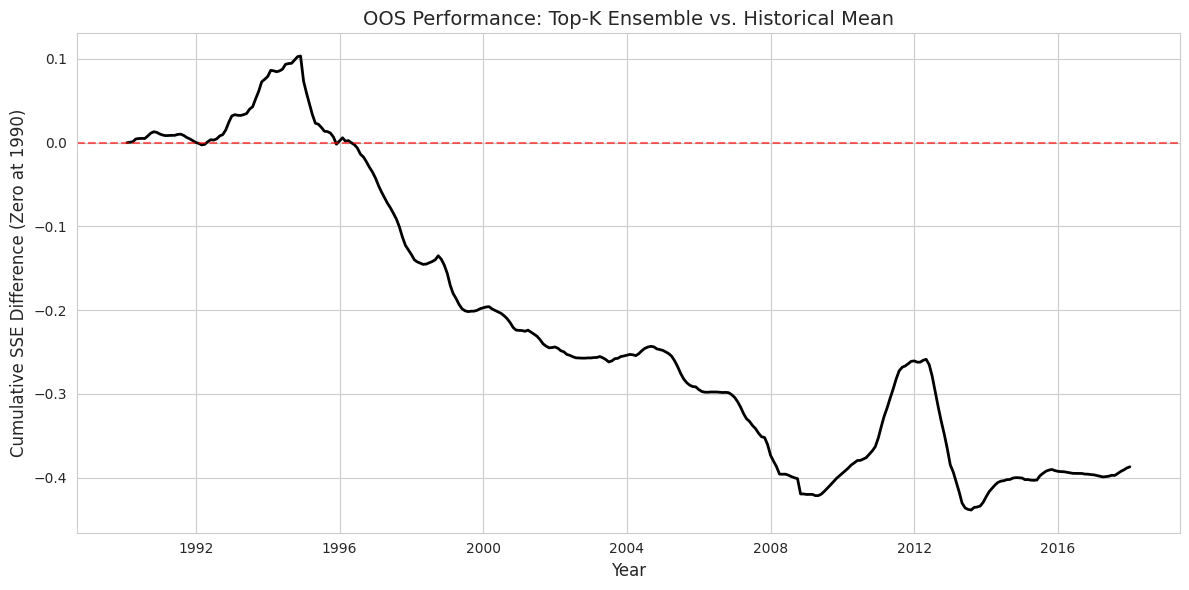

In [22]:
OOS_start = pd.Timestamp('1990-01-31')

bu.plot_cssed(y_all[:, -1], final_y_forecast[:, -1], dates, OOS_start, secondary_start=None, model_name='Top-K Ensemble')

<Axes: xlabel='date'>

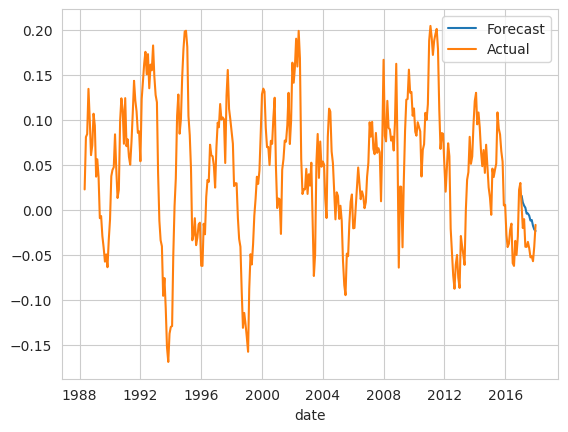

In [11]:
sns.lineplot(y=final_y_forecast[:, -1], x=yields.index, label='Forecast')
sns.lineplot(y=y_all[:, -1][200:], x=yields[200:].index, label='Actual')